# 05 CatBoost 模型解释与用户分层

## 本 notebook 目标

本 notebook 加载 04 中保存的 CatBoost 模型，并使用 SHAP 对模型预测结果进行解释。

主要任务包括：

1. 重新读取建模样本；
2. 加载 CatBoost 模型和特征列；
3. 验证模型预测一致性；
4. 计算 SHAP 特征重要性；
5. 对比高分用户和低分用户画像；
6. 根据模型分数进行用户分层；
7. 输出可落地的运营策略。

In [2]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

os.makedirs("../outputs/tables", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

In [3]:
# 1. 读取建模样本、特征列和模型
model_data_path = "../data/processed/model_data_user_level_7d.csv"
feature_cols_path = "../outputs/models/feature_cols.json"
catboost_model_path = "../outputs/models/catboost_model.cbm"

if not os.path.exists(model_data_path):
    raise FileNotFoundError(f"没有找到建模样本文件: {model_data_path}")

if not os.path.exists(feature_cols_path):
    raise FileNotFoundError(f"没有找到特征列文件: {feature_cols_path}")

if not os.path.exists(catboost_model_path):
    raise FileNotFoundError(f"没有找到 CatBoost 模型文件: {catboost_model_path}")

model_data = pd.read_csv(model_data_path)
model_data["prediction_date"] = pd.to_datetime(model_data["prediction_date"])

with open(feature_cols_path, "r", encoding="utf-8") as f:
    feature_cols = json.load(f)

cat_model = CatBoostClassifier()
cat_model.load_model(catboost_model_path)

CatBoostClassifier(class_weights=[1, 96.21569122], depth=6, eval_metric='AUC', iterations=300, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=0)

In [4]:
# 2. 复现 04 中的时间切分
unique_dates = sorted(model_data["prediction_date"].unique())

n_dates = len(unique_dates)
test_date_count = max(1, int(np.ceil(n_dates * 0.3)))

test_dates = unique_dates[-test_date_count:]
train_dates = unique_dates[:-test_date_count]

train_data = model_data[
    model_data["prediction_date"].isin(train_dates)
].copy()

test_data = model_data[
    model_data["prediction_date"].isin(test_dates)
].copy()

X_test = test_data[feature_cols].copy().fillna(0)
y_test = test_data["label"].copy()

In [5]:
# 3. 模型效果验证
cat_pred_prob = cat_model.predict_proba(X_test)[:, 1]

cat_auc = roc_auc_score(y_test, cat_pred_prob)
cat_pr_auc = average_precision_score(y_test, cat_pred_prob)

print("CatBoost AUC:", cat_auc)
print("CatBoost PR-AUC:", cat_pr_auc)

test_data["pred_prob_cat"] = cat_pred_prob

CatBoost AUC: 0.8136808174876256
CatBoost PR-AUC: 0.12770755187052996


In [6]:
# 4. 与 04 保存的预测结果做一致性检查
saved_pred_path = "../outputs/tables/test_prediction_results.csv"

if os.path.exists(saved_pred_path):
    saved_pred = pd.read_csv(saved_pred_path)

    cat_cols = [
        col for col in saved_pred.columns
        if "catboost" in col.lower() or col == "pred_prob_cat"
    ]

    if len(cat_cols) > 0 and len(saved_pred) == len(test_data):
        saved_cat_prob = saved_pred[cat_cols[0]].values

        max_abs_diff = np.max(np.abs(saved_cat_prob - cat_pred_prob))
        mean_abs_diff = np.mean(np.abs(saved_cat_prob - cat_pred_prob))

        print("与 04 保存预测结果的一致性检查:")
        print("最大绝对误差:", max_abs_diff)
        print("平均绝对误差:", mean_abs_diff)
    else:
        print("未找到可用于一致性检查的 CatBoost 预测列，或样本数不一致。")
else:
    print("未找到 04 保存的测试集预测结果，跳过一致性检查。")

与 04 保存预测结果的一致性检查:
最大绝对误差: 1.1102230246251565e-16
平均绝对误差: 2.6244138462676764e-17


,feature,mean_abs_shap
24,user_last_event_gap_hours,0.229152
2,user_view_cnt_7d,0.199756
27,user_last_view_gap_hours,0.190538
16,user_purchase_item_nunique_7d,0.187247
8,user_active_hours_7d,0.153877
31,user_view_per_active_day_7d,0.133990
29,user_purchase_rate_7d,0.121041
9,user_session_cnt_7d,0.116507
1,user_purchase_cnt_7d,0.109642
25,user_last_cart_gap_hours,0.065226


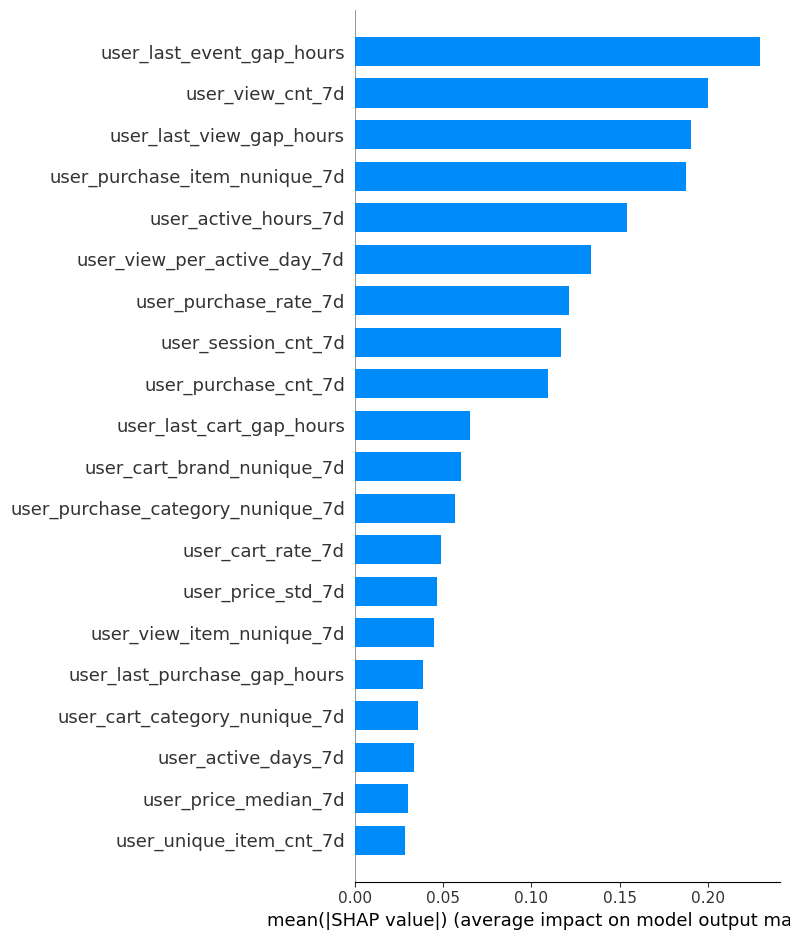

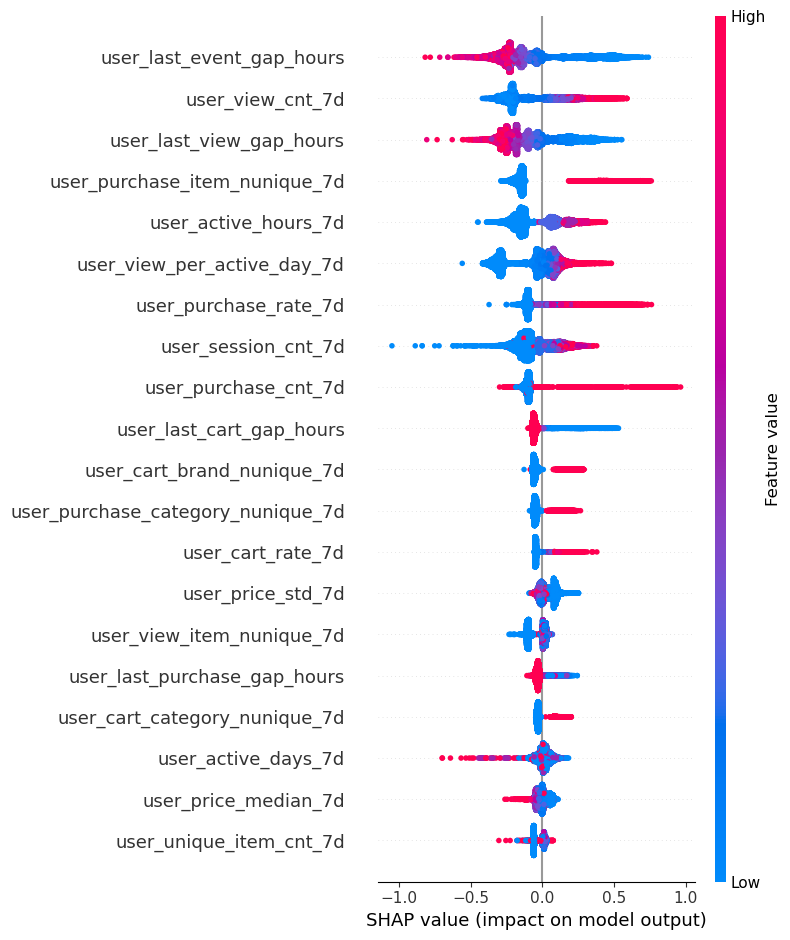

In [8]:
# 5. SHAP 解释
import shap

shap_sample_size = min(20_000, len(X_test))

X_shap = X_test.sample(
        n=shap_sample_size,
        random_state=42
)

explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_shap)

# SHAP 特征重要性：平均绝对 SHAP 值
shap_importance = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance.head(20))

shap_importance.to_csv(
     "../outputs/tables/shap_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

# SHAP bar plot
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig(
    "../outputs/figures/shap_summary_bar.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()
plt.savefig(
    "../outputs/figures/shap_summary_dot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [9]:
# 6. 高分用户 vs 低分用户画像对比(各取10%)
test_data_sorted = test_data.sort_values(
    "pred_prob_cat",
    ascending=False
).reset_index(drop=True)

top_n = int(len(test_data_sorted) * 0.10)

high_score_users = test_data_sorted.head(top_n).copy()
low_score_users = test_data_sorted.tail(top_n).copy()

print("高分用户数量:", len(high_score_users))
print("低分用户数量:", len(low_score_users))

print("\n高分用户购买率:", high_score_users["label"].mean())
print("低分用户购买率:", low_score_users["label"].mean())
print("整体购买率:", test_data_sorted["label"].mean())

profile_records = []

for col in feature_cols:
    high_mean = high_score_users[col].mean()
    low_mean = low_score_users[col].mean()
    overall_std = test_data_sorted[col].std()

    standardized_diff = (
        (high_mean - low_mean) / overall_std
        if overall_std > 0
        else np.nan
    )

    profile_records.append({
        "feature": col,
        "high_score_mean": high_mean,
        "low_score_mean": low_mean,
        "difference": high_mean - low_mean,
        "standardized_diff": standardized_diff
    })

high_low_profile = pd.DataFrame(profile_records)

high_low_profile["abs_standardized_diff"] = high_low_profile[
    "standardized_diff"
].abs()

high_low_profile = high_low_profile.sort_values(
    "abs_standardized_diff",
    ascending=False
)

display(high_low_profile.head(20))

high_low_profile.to_csv(
    "../outputs/tables/high_vs_low_score_user_profile.csv",
    index=False,
    encoding="utf-8-sig"
)

高分用户数量: 316916
低分用户数量: 316916

高分用户购买率: 0.06243294753183809
低分用户购买率: 0.002003685519191205
整体购买率: 0.0116084095257809


,feature,high_score_mean,low_score_mean,difference,standardized_diff,abs_standardized_diff
26,user_last_purchase_gap_hours,100.334890,1.919924e+02,-91.657491,-2.463848,2.463848
22,user_purchase_category_nunique_7d,0.852696,5.048656e-05,0.852645,2.292144,2.292144
19,user_purchase_brand_nunique_7d,0.819990,5.048656e-05,0.819940,2.206801,2.206801
16,user_purchase_item_nunique_7d,1.044551,5.048656e-05,1.044501,2.082854,2.082854
8,user_active_hours_7d,3.719355,1.034697e+00,2.684658,1.852749,1.852749
29,user_purchase_rate_7d,0.166798,3.063505e-08,0.166798,1.725240,1.725240
25,user_last_cart_gap_hours,139.051744,1.919892e+02,-52.937458,-1.708105,1.708105
7,user_active_days_7d,2.431524,1.026108e+00,1.405417,1.685232,1.685232
24,user_last_event_gap_hours,36.214465,1.174706e+02,-81.256165,-1.675756,1.675756
27,user_last_view_gap_hours,36.227044,1.174804e+02,-81.253404,-1.675535,1.675535


In [10]:
# 7. 用户分层
test_data["score_segment"] = pd.qcut(
    test_data["pred_prob_cat"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

score_segment_summary = (
    test_data
    .groupby("score_segment", observed=False)
    .agg(
        user_count=("user_id", "count"),
        purchase_count=("label", "sum"),
        purchase_rate=("label", "mean"),
        avg_pred_score=("pred_prob_cat", "mean")
    )
    .reset_index()
)

display(score_segment_summary)

score_segment_summary.to_csv(
    "../outputs/tables/user_score_segment_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

,score_segment,user_count,purchase_count,purchase_rate,avg_pred_score
0,Very Low,635022,1422,0.002239,0.154479
1,Low,632645,2072,0.003275,0.202159
2,Medium,633834,2900,0.004575,0.264077
3,High,633833,4929,0.007776,0.389169
4,Very High,633834,25466,0.040178,0.701341


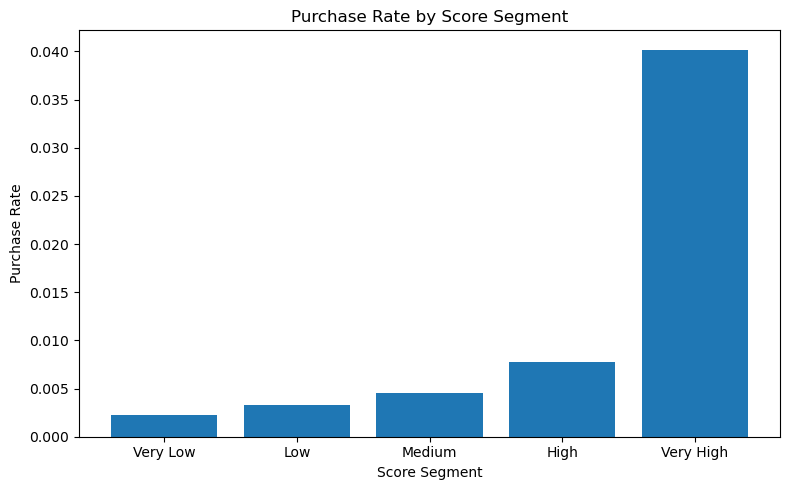

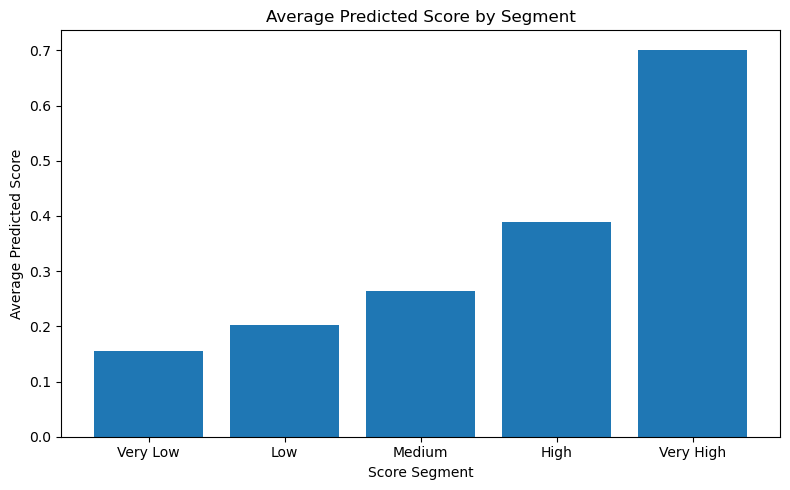

In [11]:
# 8. 用户分层可视化
plt.figure(figsize=(8, 5))

plt.bar(
    score_segment_summary["score_segment"].astype(str),
    score_segment_summary["purchase_rate"]
)

plt.title("Purchase Rate by Score Segment")
plt.xlabel("Score Segment")
plt.ylabel("Purchase Rate")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/score_segment_purchase_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(figsize=(8, 5))

plt.bar(
    score_segment_summary["score_segment"].astype(str),
    score_segment_summary["avg_pred_score"]
)

plt.title("Average Predicted Score by Segment")
plt.xlabel("Score Segment")
plt.ylabel("Average Predicted Score")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/score_segment_avg_pred_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# 9. 用户分层运营策略表
strategy_table = pd.DataFrame({
    "score_segment": ["Very High", "High", "Medium", "Low", "Very Low"],
    "user_characteristics": [
        "近期活跃、浏览或购买信号强、短期购买概率最高",
        "有较强购买倾向，但不如 Very High 稳定",
        "有一定兴趣，但转化信号不强",
        "购买意向较弱，短期转化概率较低",
        "几乎没有明显购买信号"
    ],
    "recommended_action": [
        "重点触达，限时优惠、购物车召回、库存提醒",
        "个性化推荐、优惠券测试、相似商品推荐",
        "内容种草、低成本推荐、提高兴趣",
        "降低触达频率，避免过度营销",
        "暂不重点触达，控制营销成本"
    ],
    "business_goal": [
        "提高短期转化",
        "推动潜在高意向用户转化",
        "培养用户兴趣",
        "控制成本",
        "减少无效触达"
    ]
})

display(strategy_table)

strategy_table.to_csv(
    "../outputs/tables/user_score_segment_strategy.csv",
    index=False,
    encoding="utf-8-sig"
)

,score_segment,user_characteristics,recommended_action,business_goal
0,Very High,近期活跃、浏览或购买信号强、短期购买概率最高,重点触达，限时优惠、购物车召回、库存提醒,提高短期转化
1,High,有较强购买倾向，但不如 Very High 稳定,个性化推荐、优惠券测试、相似商品推荐,推动潜在高意向用户转化
2,Medium,有一定兴趣，但转化信号不强,内容种草、低成本推荐、提高兴趣,培养用户兴趣
3,Low,购买意向较弱，短期转化概率较低,降低触达频率，避免过度营销,控制成本
4,Very Low,几乎没有明显购买信号,暂不重点触达，控制营销成本,减少无效触达


# 本节小结

1. SHAP 解释显示，最近行为间隔、浏览次数、历史购买行为、活跃小时数等特征对模型预测影响较大。
2. 高分用户通常具有近期活跃、历史购买更多、浏览强度更高等特点。
3. 用户分层结果中，预测分数越高的层级，真实购买率越高，说明模型分数具有业务排序价值。
4. 最终可以基于预测分数进行差异化运营，而不是对所有用户无差别触达。
5. 本项目是购买预测项目，用户分层表示购买概率高低，不代表严格因果意义上的营销增量高低。